<details open>
<summary><b>Assignment Overview</b></summary>

# Assignment 5: Comparative Binary Classification with XGBoost

### Name: Linn Jose  
### Student ID: 100998224  
### Course: Applied Data Analytics  

### Objective
Build a model to predict company bankruptcy using imbalanced classification.

### Key Focus
- PR-AUC (primary metric)
- Brier Score (calibration)
- Avoid overfitting
- Proper model comparison

</details>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")
df.head()


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


<details>
<summary><b>Exploratory Data Analysis (EDA)</b></summary>

This section analyzes dataset structure, class distribution, and imbalance.

</details>

In [2]:
df = pd.read_csv("data.csv")
df.shape
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [3]:
# Target distribution
df['Bankrupt?'].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [4]:
# Percentage distribution
df['Bankrupt?'].value_counts(normalize=True)

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

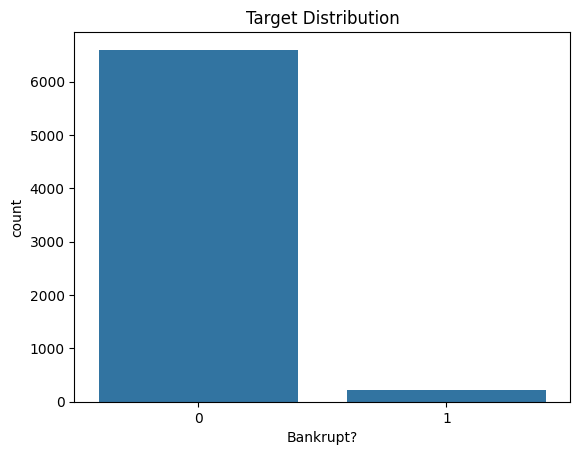

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Bankrupt?', data=df)
plt.title("Target Distribution")
plt.show()

<details>
<summary><b>Train / Validation / Test Split</b></summary>

The dataset is split using stratified sampling to preserve class distribution.

</details>

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

# First split (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [7]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 Bankrupt?
0    0.967735
1    0.032265
Name: proportion, dtype: float64

Validation distribution:
 Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64

Test distribution:
 Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


<details>
<summary><b>Preprocessing</b></summary>

Missing values are handled and all features are converted to numeric format.

</details>

In [8]:
# Preprocessing

# Handle missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Ensure all features are numeric (fix for XGBoost)
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

<details>
<summary><b>Evaluation Function</b></summary>

Reusable function to evaluate models using PR-AUC, ROC-AUC, Brier score, and classification metrics.

</details>

In [10]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, X_train, y_train, X_val, y_val, threshold=0.5):
    
    # Train model
    model.fit(X_train, y_train)
    
    # Probabilities
    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]
    
    # Metrics
    train_pr_auc = average_precision_score(y_train, train_probs)
    val_pr_auc = average_precision_score(y_val, val_probs)
    
    val_roc = roc_auc_score(y_val, val_probs)
    val_brier = brier_score_loss(y_val, val_probs)
    
    preds = (val_probs >= threshold).astype(int)
    
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    return {
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc,
        "overfit_gap": train_pr_auc - val_pr_auc,
        "val_roc_auc": val_roc,
        "val_brier": val_brier,
        "val_precision": precision,
        "val_recall": recall,
        "val_f1": f1
    }

<details>
<summary><b>Model Experiments</b></summary>

This section compares five different models using the same evaluation pipeline.

</details>

<details>
<summary><b>Experiment 1 — Logistic Regression (Baseline)</b></summary>

This baseline model provides a simple reference for comparison.

</details>

In [11]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)

res1 = evaluate_model(model1, X_train, y_train, X_val, y_val)
res1

{'train_pr_auc': 0.06106093126668735,
 'val_pr_auc': 0.04340783193388542,
 'overfit_gap': 0.01765309933280193,
 'val_roc_auc': 0.5865625956535048,
 'val_brier': 0.043268342341240766,
 'val_precision': 0.0,
 'val_recall': 0.0,
 'val_f1': 0.0}

<details>
<summary><b>Experiment 2 — XGBoost Baseline</b></summary>

First advanced model using all features.

</details>

In [12]:
from xgboost import XGBClassifier

model2 = XGBClassifier(eval_metric='logloss')

res2 = evaluate_model(model2, X_train, y_train, X_val, y_val)
res2

{'train_pr_auc': 0.9999999999999999,
 'val_pr_auc': 0.4888902436480737,
 'overfit_gap': 0.5111097563519262,
 'val_roc_auc': 0.9527089072543617,
 'val_brier': 0.02381926402449608,
 'val_precision': 0.625,
 'val_recall': 0.30303030303030304,
 'val_f1': 0.40816326530612246}

<details>
<summary><b>Experiment 3 — XGBoost with Imbalance Handling</b></summary>

Uses scale_pos_weight to address class imbalance.

</details>

In [13]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

model3 = XGBClassifier(
    scale_pos_weight=scale,
    eval_metric='logloss'
)

res3 = evaluate_model(model3, X_train, y_train, X_val, y_val)
res3

{'train_pr_auc': 0.9999999999999999,
 'val_pr_auc': 0.49448829985833814,
 'overfit_gap': 0.5055117001416618,
 'val_roc_auc': 0.9581573308846036,
 'val_brier': 0.023837953805923462,
 'val_precision': 0.5454545454545454,
 'val_recall': 0.36363636363636365,
 'val_f1': 0.43636363636363634}

<details>
<summary><b>Experiment 4 — Tuned XGBoost</b></summary>

Applies hyperparameter tuning to reduce overfitting and improve generalization.

</details>

In [14]:
model4 = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric='logloss'
)

res4 = evaluate_model(model4, X_train, y_train, X_val, y_val)
res4

{'train_pr_auc': 0.9877528318083048,
 'val_pr_auc': 0.525686707680278,
 'overfit_gap': 0.4620661241280267,
 'val_roc_auc': 0.9595653504744414,
 'val_brier': 0.021067140623927116,
 'val_precision': 0.5714285714285714,
 'val_recall': 0.24242424242424243,
 'val_f1': 0.3404255319148936}

In [15]:
importances = model2.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names)
top_features = feat_imp.nlargest(20).index

X_train_B = X_train[top_features]
X_val_B = X_val[top_features]

<details>
<summary><b>Experiment 5 — XGBoost with Reduced Features</b></summary>

Uses top selected features to test model simplicity vs performance.

</details>

In [16]:
model5 = XGBClassifier(eval_metric='logloss')

res5 = evaluate_model(model5, X_train_B, y_train, X_val_B, y_val)
res5

{'train_pr_auc': 0.9999999999999998,
 'val_pr_auc': 0.38839636500786023,
 'overfit_gap': 0.6116036349921395,
 'val_roc_auc': 0.9363942454851546,
 'val_brier': 0.026016756892204285,
 'val_precision': 0.47368421052631576,
 'val_recall': 0.2727272727272727,
 'val_f1': 0.34615384615384615}

<details>
<summary><b>Results Comparison Table</b></summary>

Summary of all experiments including performance metrics and overfitting analysis.

</details>

In [18]:
import pandas as pd

results = pd.DataFrame([
    {"exp_id": 1, "model": "Logistic", "feature_set": "A", **res1},
    {"exp_id": 2, "model": "XGB Base", "feature_set": "A", **res2},
    {"exp_id": 3, "model": "XGB Imbalance", "feature_set": "A", **res3},
    {"exp_id": 4, "model": "XGB Tuned", "feature_set": "A", **res4},
    {"exp_id": 5, "model": "XGB Reduced Features", "feature_set": "B", **res5}
])

# ADD THESE 3 LINES BELOW
results["selected_finalist"] = ["No", "No", "No", "Yes", "No"]
results["threshold"] = 0.5
results["notes"] = [
    "Baseline weak",
    "Good but overfits",
    "Handles imbalance but overfits",
    "Best balance",
    "Feature reduction worsened"
]

results

,exp_id,model,feature_set,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,val_precision,val_recall,val_f1,selected_finalist,threshold,notes
0,1,Logistic,A,0.061061,0.043408,0.017653,0.586563,0.043268,0.000000,0.000000,0.000000,No,0.5,Baseline weak
1,2,XGB Base,A,1.000000,0.488890,0.511110,0.952709,0.023819,0.625000,0.303030,0.408163,No,0.5,Good but overfits
2,3,XGB Imbalance,A,1.000000,0.494488,0.505512,0.958157,0.023838,0.545455,0.363636,0.436364,No,0.5,Handles imbalance but overfits
3,4,XGB Tuned,A,0.987753,0.525687,0.462066,0.959565,0.021067,0.571429,0.242424,0.340426,Yes,0.5,Best balance
4,5,XGB Reduced Features,B,1.000000,0.388396,0.611604,0.936394,0.026017,0.473684,0.272727,0.346154,No,0.5,Feature reduction worsened


<details>
<summary><b>Final Model Selection</b></summary>

The best model is selected based on validation PR-AUC, Brier score, and overfitting gap.

</details>

In [19]:
final_model = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=150,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric='logloss'
)


<details>
<summary><b>Final Test Evaluation</b></summary>

The selected model is evaluated on unseen test data.

</details>

In [20]:

final_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [21]:
test_probs = final_model.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

print("Test PR-AUC:", average_precision_score(y_test, test_probs))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))
print("Test Brier:", brier_score_loss(y_test, test_probs))

Test PR-AUC: 0.5203751700387619
Test ROC-AUC: 0.9577594123048669
Test Brier: 0.021884193643927574


<details>
<summary><b>Confusion Matrix Analysis</b></summary>

Shows classification results and error types.

</details>

In [23]:
from sklearn.metrics import confusion_matrix

threshold = 0.5
test_preds = (test_probs >= threshold).astype(int)

confusion_matrix(y_test, test_preds)

array([[987,   3],
       [ 24,   9]])

<details>
<summary><b>Precision-Recall Curve</b></summary>

Visualizes model performance for imbalanced classification.

</details>

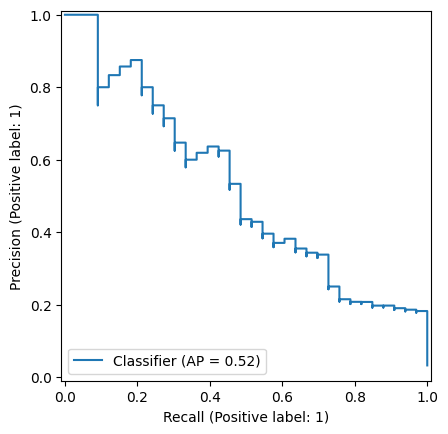

In [24]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, test_probs)

<details>
<summary><b>Calibration Curve</b></summary>

Evaluates probability calibration of the model.

</details>

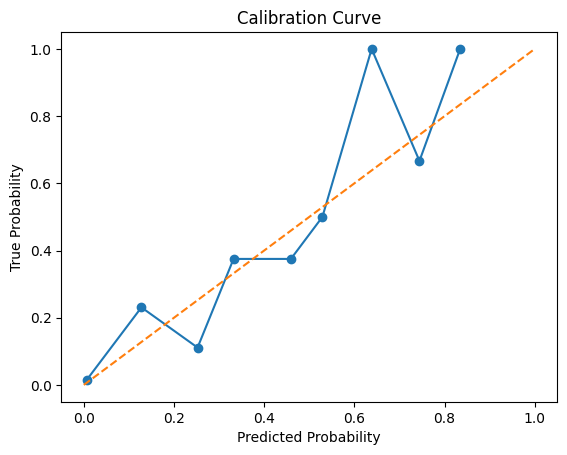

In [25]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()

<details>
<summary><b>Feature Importance</b></summary>

Highlights the most influential features in prediction.

</details>

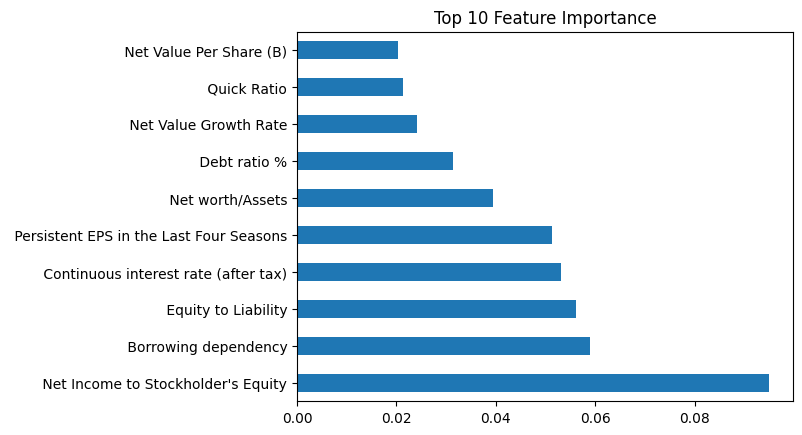

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importances = final_model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Feature Importance")
plt.show()

<details>
<summary><b>AI Usage</b></summary>

- Used Codex to structure notebook and debugging  
- Assisted in evaluation function creation  
- Helped with visualization code  
- Verified outputs manually  
- Adjusted decisions based on validation metrics  

</details>